## Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection and Preprocessing

In [2]:
# importing csv dataset into a pandas dataframe

titanic = pd.read_csv('Titanic-Dataset.csv')

In [3]:
# printing first 5 rows of the dataset

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# checking the number of rows and columns

titanic.shape

(891, 12)

## Basic checks on the dataset

In [5]:
# basic information of the dataset like null-values, data types of the columns/features

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# statistical measures of the dataset

titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# printing the feature names

titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
# checking for null or missing values

titanic.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Age, Cabin and Embarked have missing values.

In [9]:
# checking if there are any duplicate values

print(titanic.duplicated().sum())

np.int64(0)

- no duplicate values found

## Handling missing values

### Cabin

- Cabin feature has 77% missing values
- So we can drop Cabin feature as it will be of no use in building a good model

In [10]:
# dropping Cabin feature from the dataset

titanic.drop('Cabin', axis= 1, inplace= True)

In [11]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


- Successfully dropped Cabin feature

### Age

- As compared to Cabin, Age feature has less missing values
- We can impute Age feature's missing values with mean or median

<Axes: xlabel='Age'>

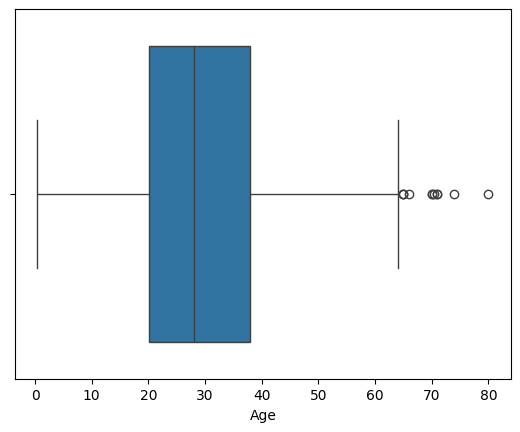

In [12]:
# checking the outliers in Age feature using boxplot
# if there are extreme outliers we have to use mode for imputation because mean/median will be useless

sns.boxplot(titanic['Age'], orient= 'h')

- there ain't any extreme outliers so we can use mean/median

In [13]:
# checking unique values in Age feature

titanic['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

- Some people's age is less than 1 and some is in fraction, which is not possible in real life

In [14]:
# imputing missing values in Age feature with mean

# titanic['Age'].fillna(titanic['Age'].mean(), inplace= True)

titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())

In [15]:
# check missing vlaues in Age feature

print(titanic['Age'].isna().sum())

0


- Successfully filled missing values in Age feature

In [16]:
# checking unique values after imputing mean in missing values

titanic['Age'].unique()

array([22.        , 38.        , 26.        , 35.        , 29.69911765,
       54.        ,  2.        , 27.        , 14.        ,  4.        ,
       58.        , 20.        , 39.        , 55.        , 31.        ,
       34.        , 15.        , 28.        ,  8.        , 19.        ,
       40.        , 66.        , 42.        , 21.        , 18.        ,
        3.        ,  7.        , 49.        , 29.        , 65.        ,
       28.5       ,  5.        , 11.        , 45.        , 17.        ,
       32.        , 16.        , 25.        ,  0.83      , 30.        ,
       33.        , 23.        , 24.        , 46.        , 59.        ,
       71.        , 37.        , 47.        , 14.5       , 70.5       ,
       32.5       , 12.        ,  9.        , 36.5       , 51.        ,
       55.5       , 40.5       , 44.        ,  1.        , 61.        ,
       56.        , 50.        , 36.        , 45.5       , 20.5       ,
       62.        , 41.        , 52.        , 63.        , 23.5 

- still some people's age is less than 1 and some is in fraction, which is not possible in real life
- We'll make Age '0' where it is less than 1 and then convert the data type of Age feature from 'float' to 'int'
- That way we can solve the above problem

In [17]:
# putting 0 where Age is less than 1

titanic.loc[titanic['Age'] < 1, 'Age'] = 0

In [18]:
# converting datatype of Age feature from float to int

titanic['Age'] = titanic['Age'].astype(int)

In [19]:
titanic['Age'].unique()

array([22, 38, 26, 35, 29, 54,  2, 27, 14,  4, 58, 20, 39, 55, 31, 34, 15,
       28,  8, 19, 40, 66, 42, 21, 18,  3,  7, 49, 65,  5, 11, 45, 17, 32,
       16, 25,  0, 30, 33, 23, 24, 46, 59, 71, 37, 47, 70, 12,  9, 36, 51,
       44,  1, 61, 56, 50, 62, 41, 52, 63, 43, 60, 10, 64, 13, 48, 53, 57,
       80,  6, 74])

In [20]:
print(titanic['Age'].isna().sum())

0


## Problem Solved

## Embarked

- Embarked feature has only 2 missing values

In [21]:
print(titanic['Embarked'].isna().sum())

2


In [22]:
titanic['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


- Majority of people are coming from port 'Southampton' so we'll impute S in those 2 missing values
- Also the data type of Embarked feature is 'object' so we cannot calculate its mean/median for imputation, that is why we are using mode

In [23]:
# below is another technique of filling missing values

titanic.loc[titanic['Embarked'].isna(), 'Embarked'] = 'S'

In [24]:
print(titanic['Embarked'].isna().sum())

0


- Successfully filled missing values in Embarked feature

In [25]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 76.7+ KB


## Successfully handled all the missing values in the dataset

In [26]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S


## Encoding - convert categorical features to numerical features

- PassengerId, Name, Ticket, these categorical features are not gonna be of much use in model training and predictions
- We won't encode Name and Ticket feature or convert them into numerical features because later we are gonna drop them when splitting data into dependent and independent features
- Also we are gonna grop PassengerId feature
- Sex and Embarked features need to be converted to numerical features

In [27]:
# Converting Sex feature using Label Encoder

from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
titanic['Sex'] = enc.fit_transform(titanic['Sex'])
titanic['Sex'].value_counts()

,count
Sex,
1,577
0,314


male --> 1

female --> 0

In [28]:
# Converting Embarked feature using Ordinal Encoder

from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories= [['S','C','Q']])
titanic['Embarked'] = enc.fit_transform(titanic[['Embarked']])
titanic['Embarked'].value_counts()

,count
Embarked,
0.0,646
1.0,168
2.0,77


In [29]:
# Converting Embarked feature data type from float to int

titanic['Embarked'] = titanic['Embarked'].astype(int)

In [30]:
# printing the data type on Embarked feature after conversion

print(titanic['Embarked'].dtype)

int64


In [31]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 76.7+ KB


In [32]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",1,35,0,0,373450,8.0500,0


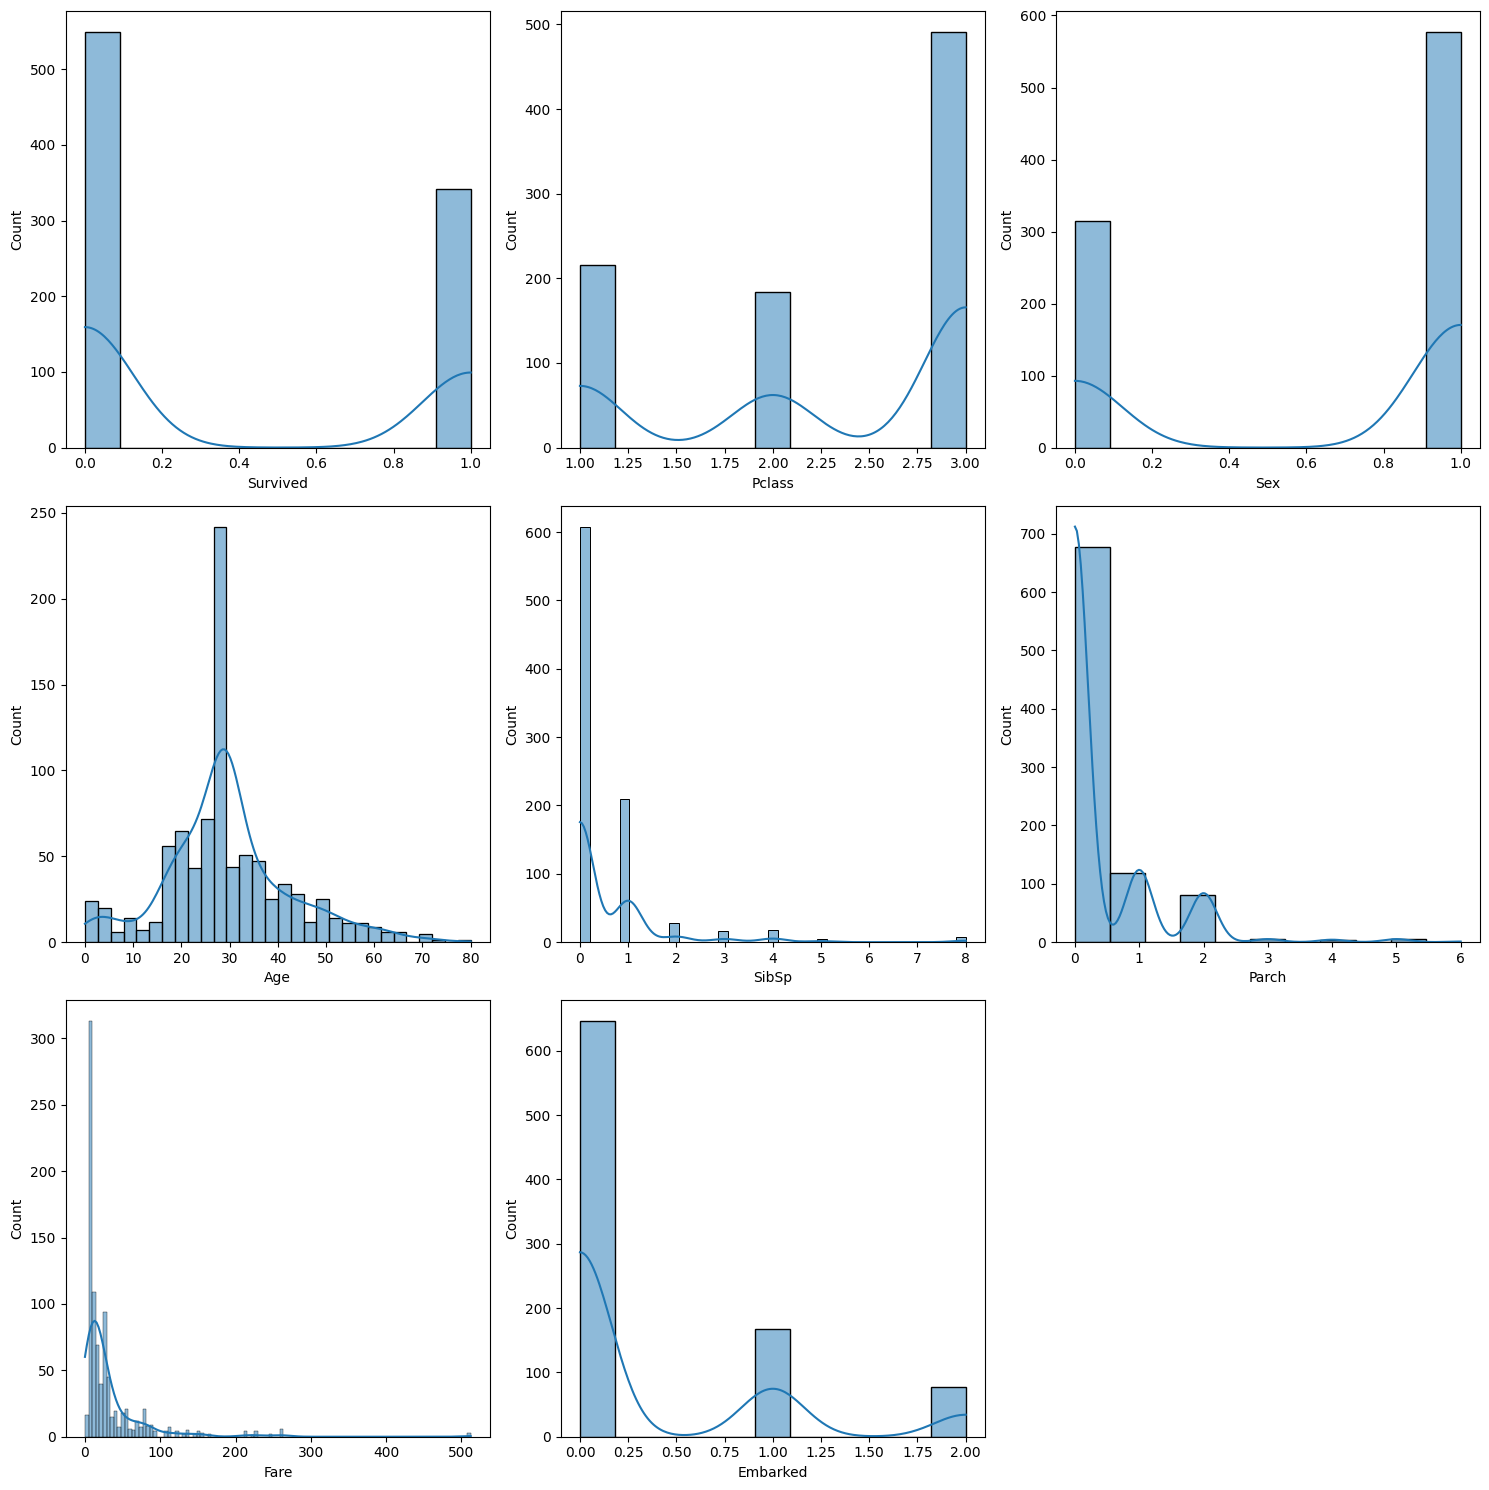

In [33]:
# plotting histplot for all numerical features except PassengerId to check distribution of the data in each feature

numerical_columns = columns = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

num_rows = 3
num_cols = (len(numerical_columns) + num_rows - 1)//num_rows

plt.figure(figsize= (15,15))
for i, col in enumerate(numerical_columns):
  plt.subplot(num_rows, num_cols, i+1)
  sns.histplot(titanic[col], kde= True)
  plt.tight_layout()
plt.show()

- Age and Fare features needs to be normalized

### Age

In [34]:
df = pd.DataFrame()
df['Age'] = titanic['Age']

In [35]:
# Logarithmic Transformation

df['Age_log'] = np.log(titanic['Age'])

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Age_log', ylabel='Count'>

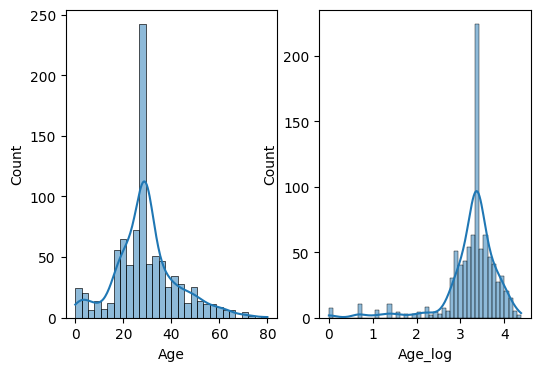

In [36]:
plt.figure(figsize = (6,4))
plt.subplot(1,2,1)
sns.histplot(titanic['Age'], kde= True)
plt.subplot(1,2,2)
sns.histplot(df['Age_log'], kde= True)

In [37]:
# Exponential Transformation

df['Age_exp']= df['Age']**(0.5)

<Axes: xlabel='Age_exp', ylabel='Count'>

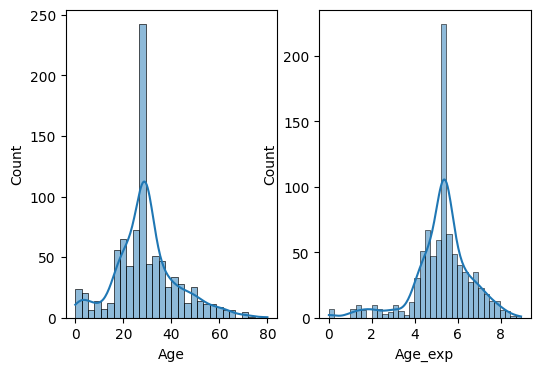

In [38]:
plt.figure(figsize = (6,4))
plt.subplot(1,2,1)
sns.histplot(titanic['Age'], kde= True)
plt.subplot(1,2,2)
sns.histplot(df['Age_exp'], kde= True)

In [39]:
# Square Root Transformation

df['Age_sqrt'] = np.sqrt(titanic['Age'])

<Axes: xlabel='Age_exp', ylabel='Count'>

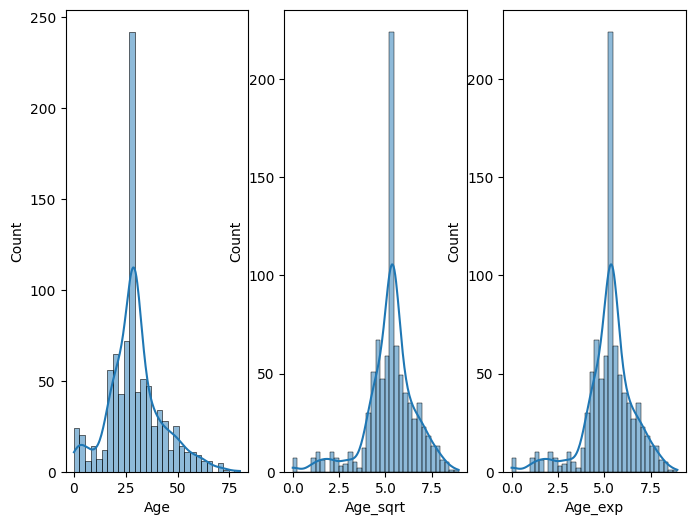

In [40]:
# comparing square root transformation and exponential transformation

plt.figure(figsize = (8,6))
plt.subplot(1,3,1)
sns.histplot(titanic['Age'], kde= True)
plt.subplot(1,3,2)
sns.histplot(df['Age_sqrt'], kde= True)
plt.subplot(1,3,3)
sns.histplot(df['Age_exp'], kde= True)

- Square root transformation and Exponential transformation gave good and almost similar results as compared to log transformation
- We'll consider using Square root transformation
- We cannot apply boxcox transformation because Age feature contains 0 (zero)

In [41]:
titanic['Age'] = df['Age_sqrt']

/tmp/ipython-input-2671020158.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((titanic['Age']), hist= False) # near to normal distribution


<Axes: xlabel='Age', ylabel='Density'>

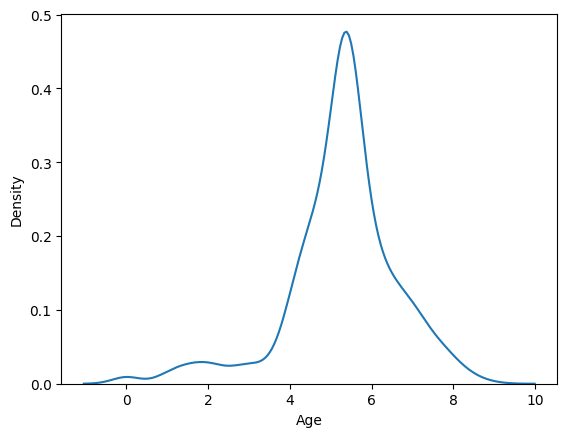

In [42]:
sns.distplot((titanic['Age']), hist= False) # near to normal distribution

### Fare

In [43]:
df['Fare'] = titanic['Fare']

In [44]:
# Logarithmic Transformation

df['Fare_log'] = np.log(titanic['Fare'])

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Fare_log', ylabel='Count'>

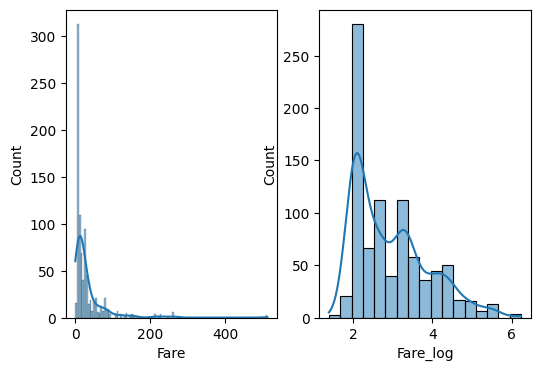

In [45]:
plt.figure(figsize = (6,4))
plt.subplot(1,2,1)
sns.histplot(titanic['Fare'], kde= True)
plt.subplot(1,2,2)
sns.histplot(df['Fare_log'], kde= True)

In [46]:
# Exponential Transformation

df['Fare_exp'] = titanic['Fare']**(0.3)
df['Fare_exp1'] = titanic['Fare']**(0.2)

<Axes: xlabel='Fare_exp1', ylabel='Count'>

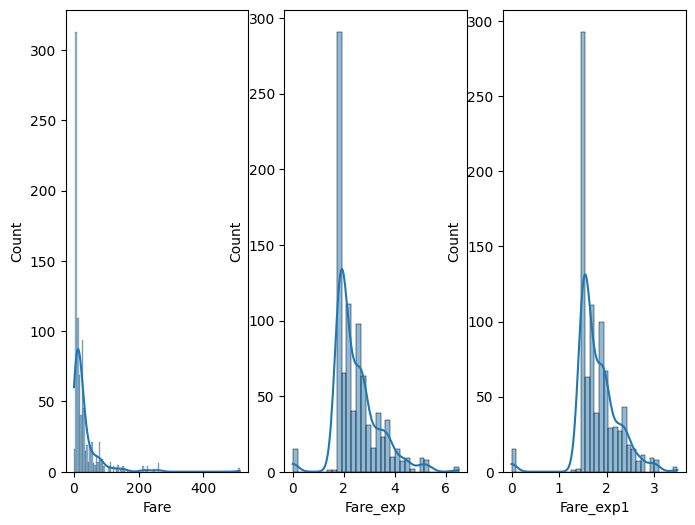

In [47]:
plt.figure(figsize = (8,6))
plt.subplot(1,3,1)
sns.histplot(titanic['Fare'], kde= True)
plt.subplot(1,3,2)
sns.histplot(df['Fare_exp'], kde= True)
plt.subplot(1,3,3)
sns.histplot(df['Fare_exp1'], kde= True)

In [48]:
# Square Root Transformation

df['Fare_sqrt'] = np.sqrt(titanic['Fare'])

<Axes: xlabel='Fare_sqrt', ylabel='Count'>

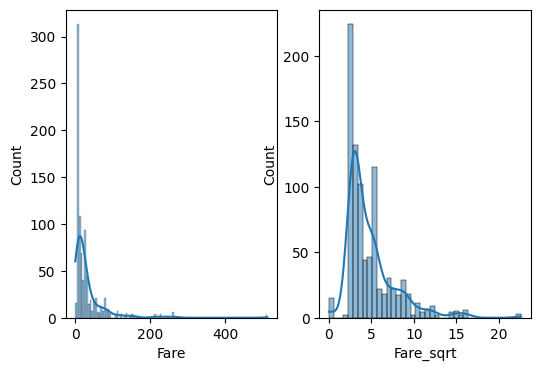

In [49]:
plt.figure(figsize = (6,4))
plt.subplot(1,2,1)
sns.histplot(titanic['Fare'], kde= True)
plt.subplot(1,2,2)

sns.histplot(df['Fare_sqrt'], kde= True)

- Exponential transformation gave good results as compared to log transformation and square root transformation
- We'll consider using Exponential transformation
- We cannot apply boxcox transformation because Fare feature contains 0 (zero)

In [50]:
titanic['Fare'] = df['Fare_exp1']

/tmp/ipython-input-2027984381.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((titanic['Fare']), hist= False) # near to normal distribution


<Axes: xlabel='Fare', ylabel='Density'>

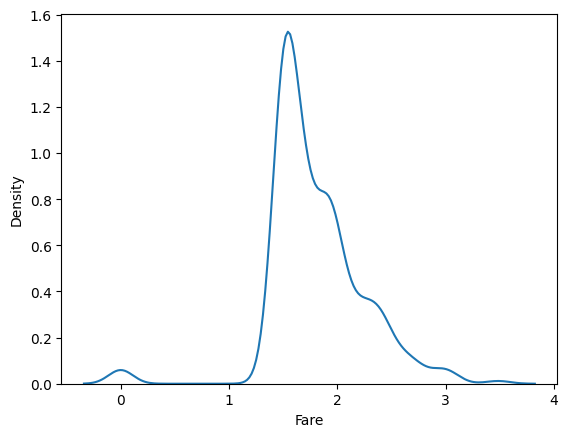

In [51]:
sns.distplot((titanic['Fare']), hist= False) # near to normal distribution

In [52]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,4.690416,1,0,A/5 21171,1.486167,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,6.164414,1,0,PC 17599,2.347457,1
2,3,1,3,"Heikkinen, Miss. Laina",0,5.099020,0,0,STON/O2. 3101282,1.512864,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,5.916080,1,0,113803,2.213191,0
4,5,0,3,"Allen, Mr. William Henry",1,5.916080,0,0,373450,1.517606,0


In [53]:
# Dropping less relevant features from the dataset

titanic.drop(['PassengerId','Name','Ticket' ], axis = 1, inplace = True)

<Axes: >

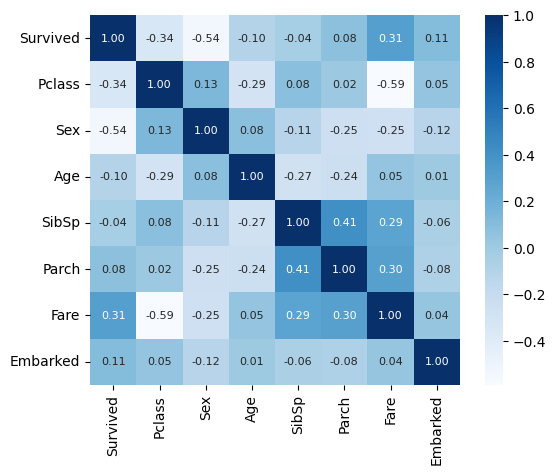

In [54]:
# plotting correlation graph between independent and dependent features

correlation = titanic.corr()
sns.heatmap(correlation, cbar= True, square= True, fmt= '.2f', annot= True, annot_kws = {'size' : 8}, cmap = 'Blues')

In [55]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,4.690416,1,0,1.486167,0
1,1,1,0,6.164414,1,0,2.347457,1
2,1,3,0,5.099020,0,0,1.512864,0
3,1,1,0,5.916080,1,0,2.213191,0
4,0,3,1,5.916080,0,0,1.517606,0


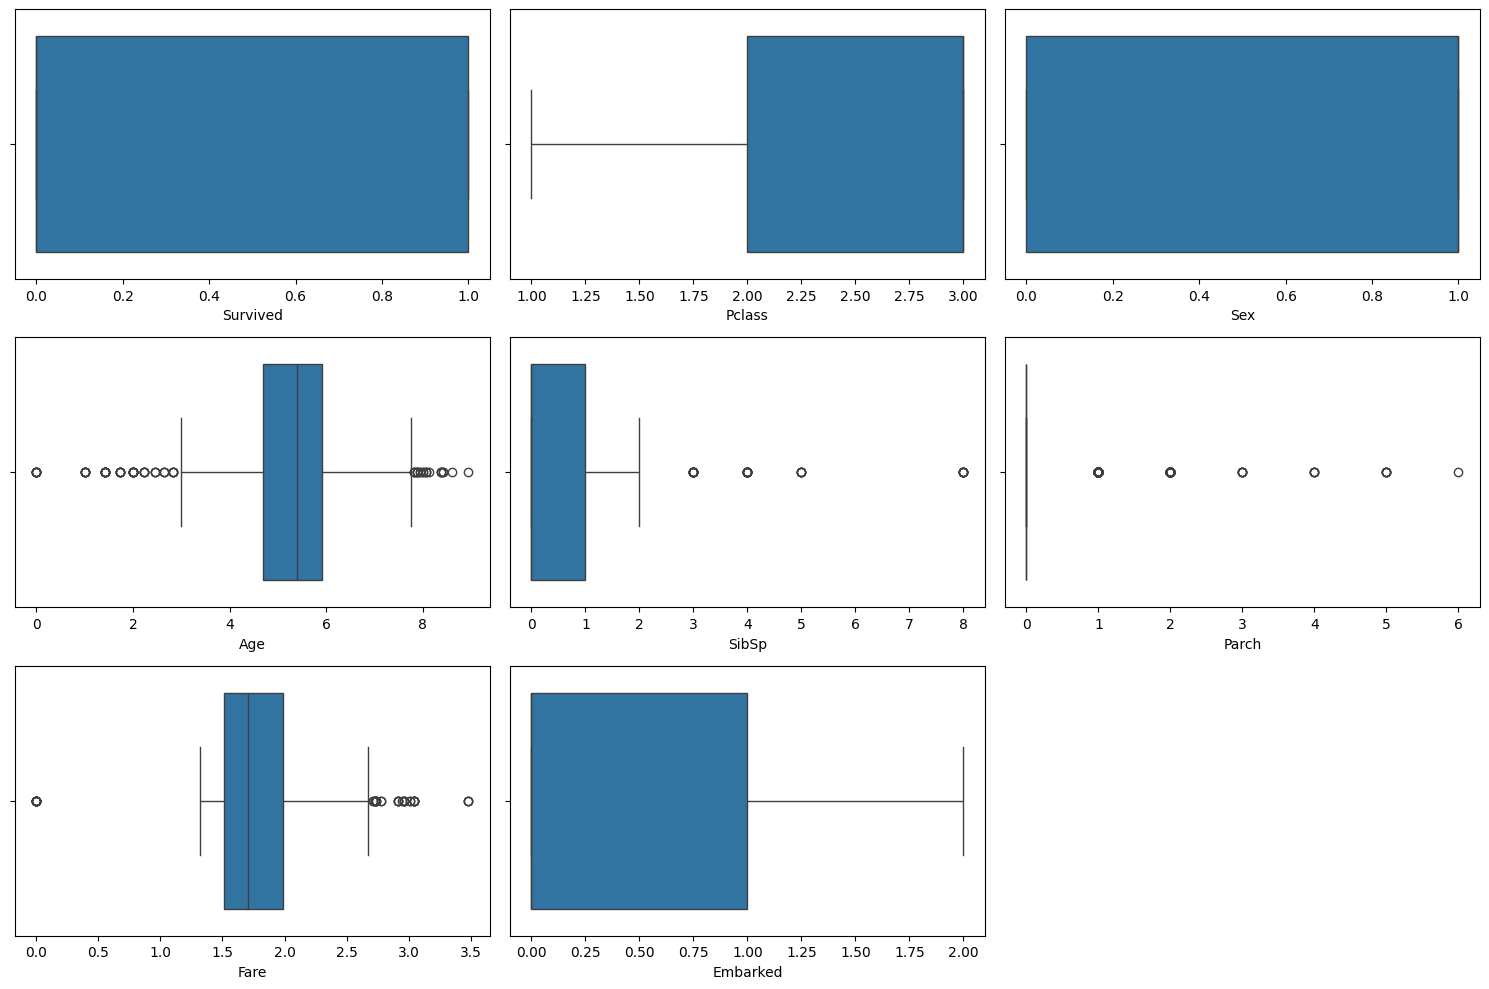

In [56]:
# Plotting boxplot for all features to check outliers in each feature

num_rows= 3
num_cols= (len(titanic.columns) + num_rows - 1)//num_rows


plt.figure(figsize= (15,10))
for i, col in enumerate(titanic.columns):
  plt.subplot(num_rows, num_cols, i+1)
  sns.boxplot(titanic[col], orient = 'h')
  plt.tight_layout()
plt.show()

- Age, SibSp, Parch, and Fare: these features have outliers

### Removing outliers from Age feature using IQR

In [57]:
Q1 = titanic['Age'].quantile(0.25)
Q3 = titanic['Age'].quantile(0.75)
IQR = Q3 - Q1

# define lower and upper bound

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# capping outliers
titanic.loc[(titanic['Age'] <= lower_bound), 'Age'] = lower_bound
titanic.loc[(titanic['Age'] >= upper_bound), 'Age'] = upper_bound

<Axes: xlabel='Age'>

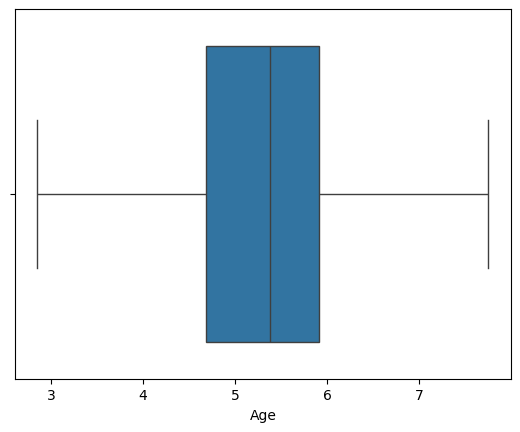

In [58]:
sns.boxplot(titanic['Age'], orient = 'h')

### Removing outliers from SibSp feature using Winsorization

In [59]:
from scipy.stats.mstats import winsorize

trim_p = 0.06
titanic['SibSp'] = winsorize(titanic['SibSp'], limits = trim_p)

<Axes: xlabel='SibSp'>

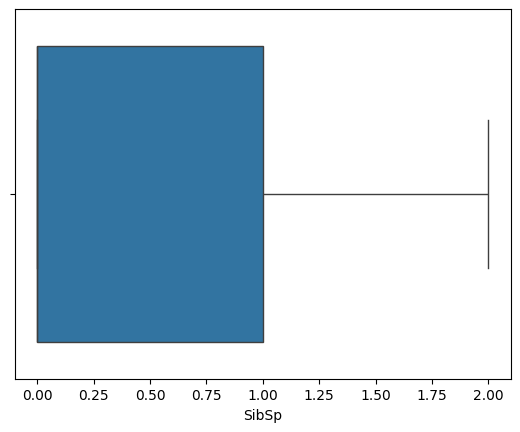

In [60]:
sns.boxplot(titanic['SibSp'], orient = 'h')

### Removing outliers from Parch feature using Winsorization

In [61]:
from scipy.stats.mstats import winsorize

trim_p = 0.3
titanic['Parch'] = winsorize(titanic['Parch'], limits = trim_p)

<Axes: xlabel='Parch'>

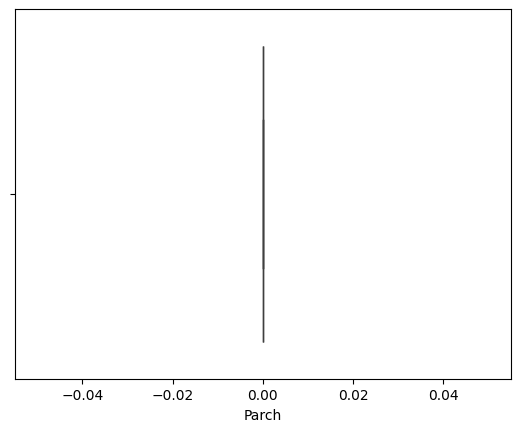

In [62]:
sns.boxplot(titanic['Parch'], orient = 'h')

### Removing outliers from Age feature using IQR

In [63]:
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1

# define lower and upper bound

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# capping outliers
titanic.loc[(titanic['Fare'] <= lower_bound), 'Fare'] = lower_bound
titanic.loc[(titanic['Fare'] >= upper_bound), 'Fare'] = upper_bound

<Axes: xlabel='Fare'>

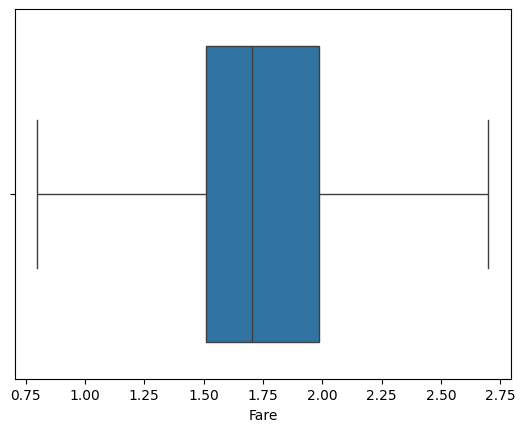

In [64]:
sns.boxplot(titanic['Fare'], orient = 'h')

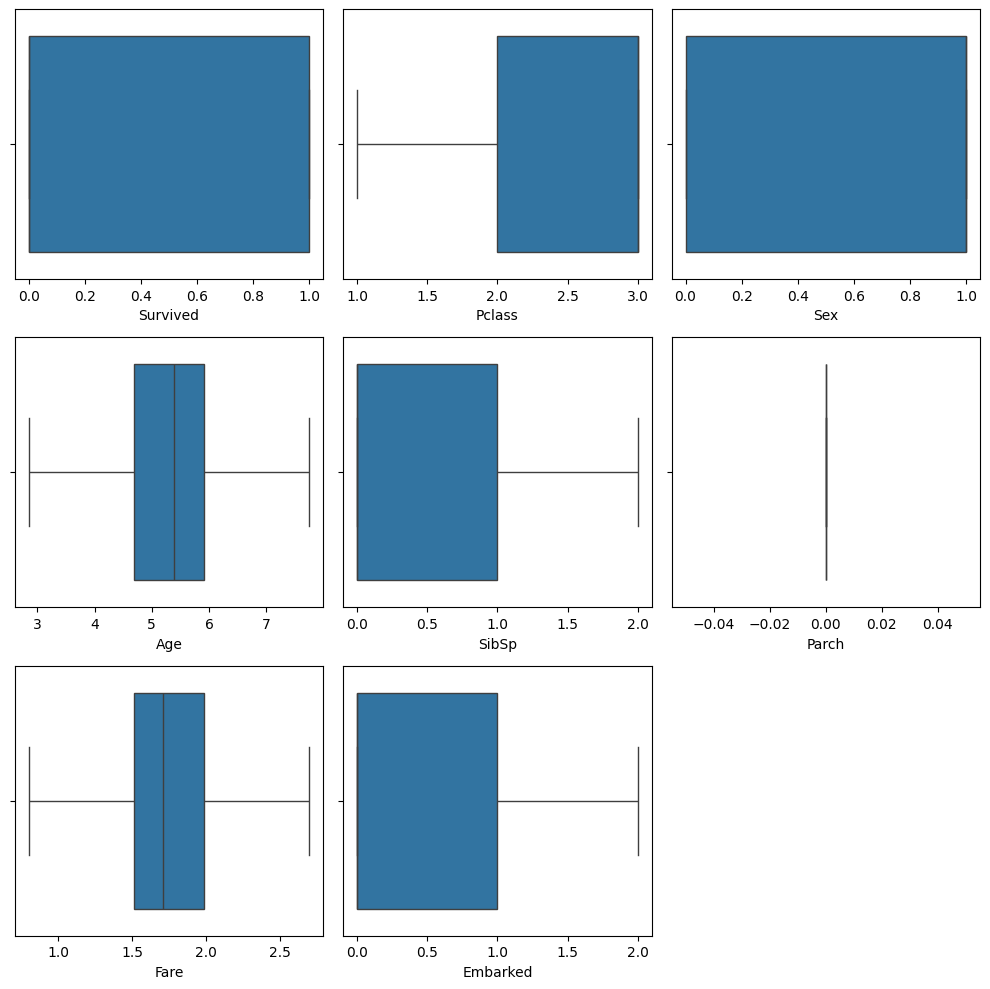

In [65]:
num_rows= 3
num_cols= (len(titanic.columns) + num_rows - 1)//num_rows


plt.figure(figsize= (10,10))
for i, col in enumerate(titanic.columns):
  plt.subplot(num_rows, num_cols, i+1)
  sns.boxplot(titanic[col], orient = 'h')
  plt.tight_layout()
plt.show()

## Successfully remode all the ourliers from the dataset

## Scaling - reduce the range of numeric features

In [66]:
titanic['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [67]:
titanic['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [68]:
# Scaling Pclass feature using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['Pclass'] = scaler.fit_transform(titanic[['Pclass']])
titanic['Pclass'].value_counts()

,count
Pclass,
1.0,491
0.0,216
0.5,184


In [69]:
titanic['Sex'].value_counts()

,count
Sex,
1,577
0,314


In [70]:
titanic['Age'].value_counts()

,count
Age,
5.385165,197
2.851920,54
4.898979,31
5.291503,27
5.477226,27
4.690416,27
4.242641,26
4.358899,25
4.582576,24


In [71]:
# Scaling Age feature using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['Age'] = scaler.fit_transform(titanic[['Age']])
titanic['Age'].value_counts()

,count
Age,
0.516709,197
0.000000,54
0.417541,31
0.497604,27
0.535486,27
0.375000,27
0.283667,26
0.307380,25
0.353004,24


In [72]:
titanic['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,74


In [73]:
# Scaling SibSp feature using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['SibSp'] = scaler.fit_transform(titanic[['SibSp']])
titanic['SibSp'].value_counts()

,count
SibSp,
0.0,608
0.5,209
1.0,74


In [74]:
titanic['Parch'].value_counts()

,count
Parch,
0,891


In [75]:
titanic['Fare'].value_counts()

,count
Fare,
1.517606,43
1.670278,42
1.511747,38
1.506123,34
1.918645,31
...,...
1.691773,1
2.191044,1
1.379730,1


In [76]:
# Scaling Fare feature using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['Fare'] = scaler.fit_transform(titanic[['Fare']])
titanic['Fare'].value_counts()

,count
Fare,
0.377790,43
0.458137,42
0.374706,38
0.371746,34
0.588847,31
...,...
0.469449,1
0.732204,1
0.305228,1


In [77]:
titanic['Embarked'].value_counts()

,count
Embarked,
0,646
1,168
2,77


In [78]:
# Scaling Embarked feature using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
titanic['Embarked'] = scaler.fit_transform(titanic[['Embarked']])
titanic['Embarked'].value_counts()

,count
Embarked,
0.0,646
0.5,168
1.0,77


In [79]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1.0,1,0.375000,0.5,0,0.361244,0.0
1,1,0.0,0,0.675653,0.5,0,0.814521,0.5
2,1,1.0,0,0.458343,0.0,0,0.375294,0.0
3,1,0.0,0,0.625000,0.5,0,0.743860,0.0
4,0,1.0,1,0.625000,0.0,0,0.377790,0.0


## Splitting the dataset into data and label

In [80]:
X = titanic.drop('Survived', axis = 1)
Y = titanic['Survived']

# Data is ready to build ML models and do predictions